In [1]:
# ==============================
# PROJECT WORK - 01
# Buyer Segmentation & Investment Profiling
# Step 1A: Load and Inspect Dataset
# ==============================

import pandas as pd
import numpy as np

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print("Clients dataset loaded successfully!")
print("Clients shape:", clients.shape)
print("\nClients columns:")
print(clients.columns.tolist())

print("\nFirst 5 rows of clients:")
display(clients.head())

print("\nClients missing values:")
print(clients.isnull().sum())

print("\nClients duplicate rows:")
print(clients.duplicated().sum())

print("\n" + "="*70 + "\n")

print("Properties dataset loaded successfully!")
print("Properties shape:", properties.shape)
print("\nProperties columns:")
print(properties.columns.tolist())

print("\nFirst 5 rows of properties:")
display(properties.head())

print("\nProperties missing values:")
print(properties.isnull().sum())

print("\nProperties duplicate rows:")
print(properties.duplicated().sum())

print("\nListing status count:")
print(properties["listing_status"].value_counts())

print("\nClient reference missing by listing status:")
print(pd.crosstab(properties["listing_status"], properties["client_ref"].isnull()))

Clients dataset loaded successfully!
Clients shape: (2000, 12)

Clients columns:
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel']

First 5 rows of clients:


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website



Clients missing values:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

Clients duplicate rows:
0


Properties dataset loaded successfully!
Properties shape: (10000, 9)

Properties columns:
['listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'client_ref']

First 5 rows of properties:


,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146



Properties missing values:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

Properties duplicate rows:
0

Listing status count:
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

Client reference missing by listing status:
client_ref      False  True 
listing_status              
Available           0   2695
Sold             7305      0


In [2]:
# ==============================
# Step 1B: Data Cleaning
# ==============================

import pandas as pd
import numpy as np

# Make copies so original data remains safe
clients_clean = clients.copy()
properties_clean = properties.copy()

# ------------------------------
# 1. Clean column names
# ------------------------------
clients_clean.columns = clients_clean.columns.str.strip().str.lower()
properties_clean.columns = properties_clean.columns.str.strip().str.lower()

# ------------------------------
# 2. Remove duplicate rows
# ------------------------------
clients_clean = clients_clean.drop_duplicates()
properties_clean = properties_clean.drop_duplicates()

# ------------------------------
# 3. Clean text/categorical columns
# ------------------------------
client_text_cols = clients_clean.select_dtypes(include=["object"]).columns
property_text_cols = properties_clean.select_dtypes(include=["object"]).columns

for col in client_text_cols:
    clients_clean[col] = clients_clean[col].astype(str).str.strip()

for col in property_text_cols:
    properties_clean[col] = properties_clean[col].astype(str).str.strip()

# Standardize important categorical labels
clients_clean["client_type"] = clients_clean["client_type"].str.title()
clients_clean["gender"] = clients_clean["gender"].str.upper()
clients_clean["acquisition_purpose"] = clients_clean["acquisition_purpose"].str.title()
clients_clean["loan_applied"] = clients_clean["loan_applied"].str.title()
clients_clean["referral_channel"] = clients_clean["referral_channel"].str.title()

properties_clean["unit_category"] = properties_clean["unit_category"].str.title()
properties_clean["listing_status"] = properties_clean["listing_status"].str.title()

# ------------------------------
# 4. Convert date columns
# ------------------------------
clients_clean["date_of_birth"] = pd.to_datetime(
    clients_clean["date_of_birth"],
    errors="coerce",
    format="mixed"
)

properties_clean["transaction_date"] = pd.to_datetime(
    properties_clean["transaction_date"],
    errors="coerce",
    format="mixed"
)

# ------------------------------
# 5. Clean sale_price column
# Remove dollar sign and comma, then convert to numeric
# ------------------------------
properties_clean["sale_price"] = (
    properties_clean["sale_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

properties_clean["sale_price"] = pd.to_numeric(
    properties_clean["sale_price"],
    errors="coerce"
)

# ------------------------------
# 6. Create age column from date_of_birth
# Use latest transaction date as reference date
# ------------------------------
reference_date = properties_clean["transaction_date"].max()

clients_clean["age"] = (
    (reference_date - clients_clean["date_of_birth"]).dt.days / 365.25
).round(0)

# ------------------------------
# 7. Keep only sold properties for buyer segmentation
# Available properties have no buyer/client reference
# ------------------------------
sold_properties = properties_clean[
    properties_clean["listing_status"] == "Sold"
].copy()

# ------------------------------
# 8. Merge clients with sold properties
# client_id in clients = client_ref in properties
# ------------------------------
merged_data = sold_properties.merge(
    clients_clean,
    left_on="client_ref",
    right_on="client_id",
    how="left"
)

# ------------------------------
# 9. Final checks
# ------------------------------
print("Clients clean shape:", clients_clean.shape)
print("Properties clean shape:", properties_clean.shape)
print("Sold properties shape:", sold_properties.shape)
print("Merged data shape:", merged_data.shape)

print("\nReference date used for age calculation:")
print(reference_date)

print("\nMissing values in cleaned clients:")
print(clients_clean.isnull().sum())

print("\nMissing values in sold properties:")
print(sold_properties.isnull().sum())

print("\nMissing values in merged data:")
print(merged_data.isnull().sum())

print("\nData types after cleaning:")
print(merged_data.dtypes)

print("\nFirst 5 rows of merged data:")
display(merged_data.head())

Clients clean shape: (2000, 13)
Properties clean shape: (10000, 9)
Sold properties shape: (7305, 9)
Merged data shape: (7305, 22)

Reference date used for age calculation:
2025-12-01 00:00:00

Missing values in cleaned clients:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
age                    0
dtype: int64

Missing values in sold properties:
listing_id          0
tower_number        0
transaction_date    0
unit_category       0
unit_number         0
floor_area_sqft     0
sale_price          0
listing_status      0
client_ref          0
dtype: int64

Missing values in merged data:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,1012,1,2024-01-01,Apartment,12,1160.36,300385.62,Sold,C0027,C0027,...,Weber,1968-09-08,M,USA,California,Home,5,Yes,Website,57.0
1,1015,1,2024-01-01,Apartment,15,782.25,208930.81,Sold,C0097,C0097,...,Mack,1943-06-18,M,USA,Virginia,Home,5,Yes,Website,82.0
2,1021,1,2024-01-01,Apartment,21,756.21,218585.92,Sold,C0113,C0113,...,Bray,1949-07-14,M,USA,Utah,Investment,4,No,Agency,76.0
3,1030,1,2024-01-01,Apartment,30,743.09,246172.68,Sold,C0141,C0141,...,Mercer,1986-06-21,F,USA,California,Home,5,No,Website,39.0
4,2016,2,2024-01-01,Apartment,16,701.66,212265.67,Sold,C0146,C0146,...,Ayers,1963-02-01,M,USA,Colorado,Home,2,No,Website,63.0


In [3]:
# ==============================
# Step 1C: Create Buyer-Level Profile Dataset
# ==============================

# Helper function to find most frequent value
def mode_value(x):
    return x.mode()[0] if not x.mode().empty else np.nan

buyer_profile = merged_data.groupby("client_id").agg(
    # Buyer demographic/profile fields
    client_type=("client_type", "first"),
    gender=("gender", "first"),
    country=("country", "first"),
    region=("region", "first"),
    acquisition_purpose=("acquisition_purpose", "first"),
    satisfaction_score=("satisfaction_score", "first"),
    loan_applied=("loan_applied", "first"),
    referral_channel=("referral_channel", "first"),
    age=("age", "first"),

    # Property purchase behavior
    total_properties_bought=("listing_id", "count"),
    total_investment=("sale_price", "sum"),
    avg_property_price=("sale_price", "mean"),
    max_property_price=("sale_price", "max"),
    min_property_price=("sale_price", "min"),
    avg_floor_area_sqft=("floor_area_sqft", "mean"),
    total_floor_area_sqft=("floor_area_sqft", "sum"),

    # Preference behavior
    preferred_unit_category=("unit_category", mode_value),
    preferred_tower=("tower_number", mode_value),

    # Transaction timeline
    first_purchase_date=("transaction_date", "min"),
    last_purchase_date=("transaction_date", "max")
).reset_index()

# Create additional investment intensity features
buyer_profile["investment_per_sqft"] = (
    buyer_profile["total_investment"] / buyer_profile["total_floor_area_sqft"]
)

buyer_profile["avg_price_per_sqft"] = (
    buyer_profile["avg_property_price"] / buyer_profile["avg_floor_area_sqft"]
)

# Calculate buying duration
buyer_profile["purchase_duration_days"] = (
    buyer_profile["last_purchase_date"] - buyer_profile["first_purchase_date"]
).dt.days

# Replace infinite values if any
buyer_profile = buyer_profile.replace([np.inf, -np.inf], np.nan)

# Final check
print("Buyer profile shape:", buyer_profile.shape)

print("\nMissing values in buyer profile:")
print(buyer_profile.isnull().sum())

print("\nDuplicate client IDs:")
print(buyer_profile["client_id"].duplicated().sum())

print("\nFirst 5 rows of buyer profile:")
display(buyer_profile.head())

print("\nBasic summary of numeric buyer profile:")
display(buyer_profile.describe())

print("\nBuyer count by client type:")
print(buyer_profile["client_type"].value_counts())

print("\nBuyer count by acquisition purpose:")
print(buyer_profile["acquisition_purpose"].value_counts())

print("\nBuyer count by loan applied:")
print(buyer_profile["loan_applied"].value_counts())

print("\nTop 10 countries:")
print(buyer_profile["country"].value_counts().head(10))

print("\nTop 10 regions:")
print(buyer_profile["region"].value_counts().head(10))

Buyer profile shape: (2000, 24)

Missing values in buyer profile:
client_id                  0
client_type                0
gender                     0
country                    0
region                     0
acquisition_purpose        0
satisfaction_score         0
loan_applied               0
referral_channel           0
age                        0
total_properties_bought    0
total_investment           0
avg_property_price         0
max_property_price         0
min_property_price         0
avg_floor_area_sqft        0
total_floor_area_sqft      0
preferred_unit_category    0
preferred_tower            0
first_purchase_date        0
last_purchase_date         0
investment_per_sqft        0
avg_price_per_sqft         0
purchase_duration_days     0
dtype: int64

Duplicate client IDs:
0

First 5 rows of buyer profile:


,client_id,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,...,min_property_price,avg_floor_area_sqft,total_floor_area_sqft,preferred_unit_category,preferred_tower,first_purchase_date,last_purchase_date,investment_per_sqft,avg_price_per_sqft,purchase_duration_days
0,C0001,Individual,F,USA,California,Home,4,Yes,Website,58.0,...,175599.90,983.885000,3935.54,Apartment,3,2024-10-01,2025-12-01,316.796353,316.796353,426
1,C0002,Individual,M,USA,California,Home,1,No,Website,63.0,...,248525.12,1187.942000,5939.71,Apartment,1,2024-01-01,2025-12-01,309.963943,309.963943,700
2,C0003,Individual,M,USA,California,Home,4,Yes,Agency,67.0,...,216874.97,1058.110000,5290.55,Apartment,1,2024-07-01,2025-10-01,314.042508,314.042508,457
3,C0004,Individual,M,USA,California,Home,5,No,Website,66.0,...,149009.73,937.103333,5622.62,Apartment,4,2024-02-01,2025-08-01,286.034537,286.034537,547
4,C0005,Company,M,USA,California,Investment,5,No,Website,50.0,...,189194.31,927.296154,12054.85,Apartment,1,2024-02-01,2025-05-01,303.063529,303.063529,455



Basic summary of numeric buyer profile:


,satisfaction_score,age,total_properties_bought,total_investment,avg_property_price,max_property_price,min_property_price,avg_floor_area_sqft,total_floor_area_sqft,preferred_tower,first_purchase_date,last_purchase_date,investment_per_sqft,avg_price_per_sqft,purchase_duration_days
count,2000.000000,2000.00000,2000.0000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000,2000.000000,2000.000000,2000.000000
mean,3.029000,55.51150,3.6525,1.260375e+06,347089.955869,480546.955875,224050.808565,1147.479668,4168.042480,3.423000,2024-04-27 07:39:21.600000,2025-06-01 11:18:14.400000,302.448337,302.448337,400.152000
min,1.000000,25.00000,3.0000,4.636120e+05,154537.316667,193265.770000,97402.800000,564.010000,1692.030000,1.000000,2024-01-01 00:00:00,2024-02-01 00:00:00,244.869303,244.869303,0.000000
25%,2.000000,41.00000,3.0000,1.025238e+06,295807.677708,411678.305000,172516.102500,984.952500,3387.530000,2.000000,2024-02-01 00:00:00,2025-02-22 00:00:00,290.904842,290.904842,274.000000
50%,3.000000,56.00000,4.0000,1.220893e+06,341523.383333,488390.735000,208244.365000,1129.176667,4061.095000,3.000000,2024-04-01 00:00:00,2025-07-01 00:00:00,302.344676,302.344676,397.000000
75%,4.000000,70.00000,4.0000,1.441974e+06,390843.316875,550353.952500,254233.170000,1296.562500,4740.327500,5.000000,2024-07-01 00:00:00,2025-10-01 00:00:00,313.524891,313.524891,518.000000
max,5.000000,95.00000,13.0000,3.653385e+06,563423.500000,736652.270000,532909.350000,1800.450000,12054.850000,16.000000,2025-09-01 00:00:00,2025-12-01 00:00:00,376.904672,376.904672,700.000000
std,1.413562,17.35337,0.8397,3.478307e+05,69721.821814,94300.835147,73029.873713,219.922587,1130.165735,1.758299,NaN,NaN,17.005724,17.005724,161.430126



Buyer count by client type:
client_type
Individual    1897
Company        103
Name: count, dtype: int64

Buyer count by acquisition purpose:
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

Buyer count by loan applied:
loan_applied
No     1264
Yes     736
Name: count, dtype: int64

Top 10 countries:
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

Top 10 regions:
region
California    633
Nevada        143
Colorado      118
Arizona       108
Oregon         96
Utah           87
Washington     73
Virginia       65
Texas          56
Florida        50
Name: count, dtype: int64


In [4]:
# ==============================
# Step 2 + Step 3: Feature Encoding and Scaling
# ==============================

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Make a copy
cluster_data = buyer_profile.copy()

# ------------------------------
# 1. Select useful clustering features
# ------------------------------

categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel",
    "preferred_unit_category"
]

numeric_features = [
    "satisfaction_score",
    "age",
    "total_properties_bought",
    "total_investment",
    "avg_property_price",
    "max_property_price",
    "min_property_price",
    "avg_floor_area_sqft",
    "total_floor_area_sqft",
    "investment_per_sqft",
    "avg_price_per_sqft",
    "purchase_duration_days"
]

# Keep only selected features
X = cluster_data[categorical_features + numeric_features].copy()

# ------------------------------
# 2. One-Hot Encoding for categorical variables
# ------------------------------
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False
)

# ------------------------------
# 3. Feature Scaling for numeric variables
# ------------------------------
scaler = StandardScaler()

X_encoded[numeric_features] = scaler.fit_transform(
    X_encoded[numeric_features]
)

# ------------------------------
# 4. Final checks
# ------------------------------
print("Original buyer profile shape:", buyer_profile.shape)
print("Clustering dataset shape after encoding:", X_encoded.shape)

print("\nSelected categorical features:")
print(categorical_features)

print("\nSelected numeric features:")
print(numeric_features)

print("\nMissing values in encoded dataset:")
print(X_encoded.isnull().sum().sum())

print("\nFirst 5 rows of encoded and scaled dataset:")
display(X_encoded.head())

print("\nEncoded feature columns:")
print(X_encoded.columns.tolist())

Original buyer profile shape: (2000, 24)
Clustering dataset shape after encoding: (2000, 92)

Selected categorical features:
['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel', 'preferred_unit_category']

Selected numeric features:
['satisfaction_score', 'age', 'total_properties_bought', 'total_investment', 'avg_property_price', 'max_property_price', 'min_property_price', 'avg_floor_area_sqft', 'total_floor_area_sqft', 'investment_per_sqft', 'avg_price_per_sqft', 'purchase_duration_days']

Missing values in encoded dataset:
0

First 5 rows of encoded and scaled dataset:


,satisfaction_score,age,total_properties_bought,total_investment,avg_property_price,max_property_price,min_property_price,avg_floor_area_sqft,total_floor_area_sqft,investment_per_sqft,...,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website,preferred_unit_category_Apartment,preferred_unit_category_Office
0,0.687089,0.143437,0.413942,-0.039140,-0.507841,0.166736,-0.663605,-0.744060,-0.205776,0.843928,...,False,True,False,False,True,False,False,True,True,False
1,-1.435740,0.431638,1.605141,1.669967,0.303126,0.260728,0.335211,0.184030,1.568009,0.442056,...,False,True,False,True,False,False,False,True,True,False
2,0.687089,0.662198,1.605141,1.153384,-0.212303,1.103819,-0.098284,-0.406470,0.993472,0.681951,...,False,True,False,False,True,True,False,False,True,False
3,1.394698,0.604558,2.796340,1.000415,-1.134018,1.337415,-1.027796,-0.956832,1.287370,-0.965434,...,False,True,False,True,False,False,False,True,True,False
4,1.394698,-0.317683,11.134734,6.881534,-0.947721,1.572653,-0.477410,-1.001437,6.980197,0.036185,...,False,False,True,True,False,False,False,True,True,False



Encoded feature columns:
['satisfaction_score', 'age', 'total_properties_bought', 'total_investment', 'avg_property_price', 'max_property_price', 'min_property_price', 'avg_floor_area_sqft', 'total_floor_area_sqft', 'investment_per_sqft', 'avg_price_per_sqft', 'purchase_duration_days', 'client_type_Company', 'client_type_Individual', 'gender_F', 'gender_M', 'country_Australia', 'country_Belgium', 'country_Canada', 'country_Denmark', 'country_France', 'country_Germany', 'country_Mexico', 'country_Russia', 'country_UK', 'country_USA', 'region_Alberta', 'region_Arizona', 'region_Baja California', 'region_Bavaria', 'region_Berlin', 'region_British Columbia', 'region_Brittany', 'region_Brussels', 'region_California', 'region_Capital Region', 'region_Central Denmark', 'region_Colorado', 'region_England', 'region_Flanders', 'region_Florida', 'region_Georgia', 'region_Hamburg', 'region_Hesse', 'region_Ile-de-France', 'region_Jalisco', 'region_Kansas', 'region_Krasnodar Krai', 'region_Manitoba

K-Means evaluation results:


,k,inertia,silhouette_score
0,2,25237.717442,0.157900
1,3,23347.460088,0.123751
2,4,21733.705235,0.110613
3,5,20333.076676,0.104505
4,6,19517.914447,0.095711
5,7,18875.890960,0.092113
6,8,18370.567739,0.084859
7,9,18001.867182,0.081434
8,10,17679.636819,0.080153



Best k based on Silhouette Score: 2


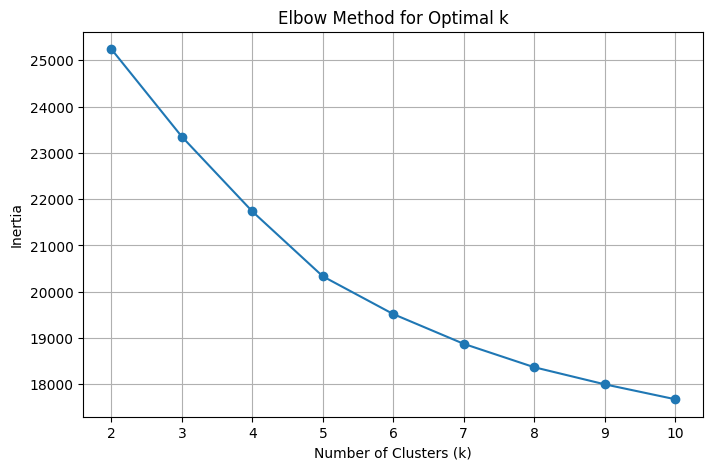

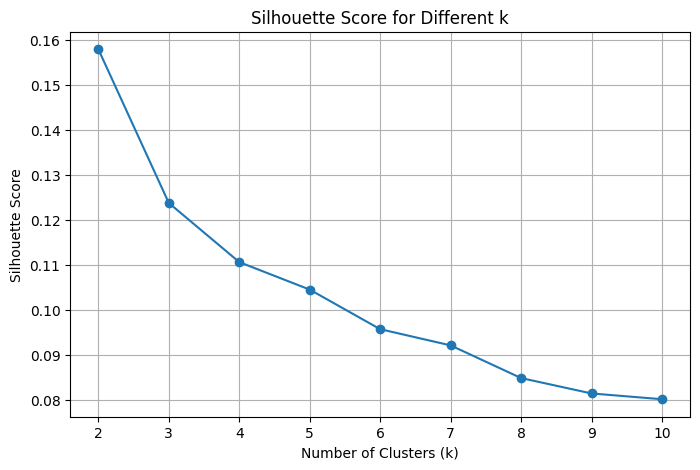

In [5]:
# ==============================
# Step 4A: K-Means Elbow Method + Silhouette Score
# ==============================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert all values to float for safe clustering
X_cluster = X_encoded.astype(float)

# Store results
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_cluster)

    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, cluster_labels))

# Create result table
kmeans_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_scores,
    "silhouette_score": silhouette_scores
})

print("K-Means evaluation results:")
display(kmeans_eval)

best_k_silhouette = kmeans_eval.loc[
    kmeans_eval["silhouette_score"].idxmax(), "k"
]

print("\nBest k based on Silhouette Score:", best_k_silhouette)

# ------------------------------
# Elbow Method Plot
# ------------------------------
plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# ------------------------------
# Silhouette Score Plot
# ------------------------------
plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["k"], kmeans_eval["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.grid(True)
plt.show()

In [6]:
# ==============================
# Step 4B: Final K-Means Model with k = 4
# ==============================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Final number of clusters
final_k = 4

# Train final K-Means model
final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

# Predict clusters
buyer_profile["cluster"] = final_kmeans.fit_predict(X_cluster)

# Calculate final silhouette score
final_silhouette = silhouette_score(X_cluster, buyer_profile["cluster"])

print("Final K-Means model trained successfully!")
print("Final number of clusters:", final_k)
print("Final silhouette score:", final_silhouette)

print("\nCluster counts:")
print(buyer_profile["cluster"].value_counts().sort_index())

print("\nCluster percentage distribution:")
print((buyer_profile["cluster"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nFirst 10 rows with cluster labels:")
display(buyer_profile[[
    "client_id",
    "client_type",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "satisfaction_score",
    "age",
    "total_properties_bought",
    "total_investment",
    "avg_property_price",
    "cluster"
]].head(10))

# Save clustered buyer profile for later dashboard/report
buyer_profile.to_csv("buyer_profile_clustered.csv", index=False)

print("\nClustered buyer profile saved as: buyer_profile_clustered.csv")

Final K-Means model trained successfully!
Final number of clusters: 4
Final silhouette score: 0.11061316286138376

Cluster counts:
cluster
0    614
1     87
2    663
3    636
Name: count, dtype: int64

Cluster percentage distribution:
cluster
0    30.70
1     4.35
2    33.15
3    31.80
Name: proportion, dtype: float64

First 10 rows with cluster labels:


,client_id,client_type,country,region,acquisition_purpose,loan_applied,satisfaction_score,age,total_properties_bought,total_investment,avg_property_price,cluster
0,C0001,Individual,USA,California,Home,Yes,4,58.0,4,1246764.72,311691.180000,0
1,C0002,Individual,USA,California,Home,No,1,63.0,5,1841095.93,368219.186000,1
2,C0003,Individual,USA,California,Home,Yes,4,67.0,5,1661457.59,332291.518000,1
3,C0004,Individual,USA,California,Home,No,5,66.0,6,1608263.51,268043.918333,1
4,C0005,Company,USA,California,Investment,No,5,50.0,13,3653385.38,281029.644615,1
5,C0006,Individual,USA,California,Home,Yes,3,69.0,5,1514131.06,302826.212000,0
6,C0007,Individual,Canada,Quebec,Investment,No,5,79.0,11,3251147.83,295558.893636,1
7,C0008,Individual,USA,California,Home,No,5,56.0,5,1476730.41,295346.082000,3
8,C0009,Individual,USA,California,Investment,No,5,50.0,5,1820832.35,364166.470000,1
9,C0010,Individual,USA,Oregon,Investment,No,3,59.0,5,1732434.00,346486.800000,1



Clustered buyer profile saved as: buyer_profile_clustered.csv


In [7]:
# ==============================
# Step 4C: Cluster Interpretation Table
# ==============================

import pandas as pd
import numpy as np

# ------------------------------
# 1. Numeric cluster summary
# ------------------------------

numeric_summary = buyer_profile.groupby("cluster").agg(
    buyer_count=("client_id", "count"),
    avg_age=("age", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_properties_bought=("total_properties_bought", "mean"),
    avg_total_investment=("total_investment", "mean"),
    avg_property_price=("avg_property_price", "mean"),
    avg_max_property_price=("max_property_price", "mean"),
    avg_floor_area_sqft=("avg_floor_area_sqft", "mean"),
    avg_total_floor_area=("total_floor_area_sqft", "mean"),
    avg_investment_per_sqft=("investment_per_sqft", "mean"),
    avg_purchase_duration_days=("purchase_duration_days", "mean")
).reset_index()

# Round numeric values
numeric_summary = numeric_summary.round(2)

print("Numeric Cluster Summary:")
display(numeric_summary)

# ------------------------------
# 2. Categorical cluster summary
# ------------------------------

def top_category(series):
    return series.value_counts().idxmax()

def top_category_percentage(series):
    return round(series.value_counts(normalize=True).max() * 100, 2)

categorical_summary = buyer_profile.groupby("cluster").agg(
    dominant_client_type=("client_type", top_category),
    client_type_percentage=("client_type", top_category_percentage),

    dominant_country=("country", top_category),
    country_percentage=("country", top_category_percentage),

    dominant_region=("region", top_category),
    region_percentage=("region", top_category_percentage),

    dominant_acquisition_purpose=("acquisition_purpose", top_category),
    acquisition_purpose_percentage=("acquisition_purpose", top_category_percentage),

    dominant_loan_status=("loan_applied", top_category),
    loan_status_percentage=("loan_applied", top_category_percentage),

    dominant_referral_channel=("referral_channel", top_category),
    referral_channel_percentage=("referral_channel", top_category_percentage),

    dominant_unit_category=("preferred_unit_category", top_category),
    unit_category_percentage=("preferred_unit_category", top_category_percentage)
).reset_index()

print("\nCategorical Cluster Summary:")
display(categorical_summary)

# ------------------------------
# 3. Combined cluster profile table
# ------------------------------

cluster_profile_summary = numeric_summary.merge(
    categorical_summary,
    on="cluster",
    how="left"
)

print("\nFinal Combined Cluster Profile Summary:")
display(cluster_profile_summary)

# Save for report
cluster_profile_summary.to_csv("cluster_profile_summary.csv", index=False)

print("\nCluster profile summary saved as: cluster_profile_summary.csv")

Numeric Cluster Summary:


,cluster,buyer_count,avg_age,avg_satisfaction,avg_properties_bought,avg_total_investment,avg_property_price,avg_max_property_price,avg_floor_area_sqft,avg_total_floor_area,avg_investment_per_sqft,avg_purchase_duration_days
0,0,614,54.91,2.85,3.59,1158513.61,324368.94,477177.70,1030.22,3683.49,315.16,412.71
1,1,87,63.68,3.53,6.33,2147601.19,342983.85,529116.72,1138.88,7126.49,301.26,515.94
2,2,663,54.45,3.06,3.51,1474309.47,422852.25,552835.31,1387.30,4839.35,304.86,394.51
3,3,636,56.08,3.10,3.50,1014331.96,290608.10,401798.49,1011.85,3531.34,287.82,378.07



Categorical Cluster Summary:


,cluster,dominant_client_type,client_type_percentage,dominant_country,country_percentage,dominant_region,region_percentage,dominant_acquisition_purpose,acquisition_purpose_percentage,dominant_loan_status,loan_status_percentage,dominant_referral_channel,referral_channel_percentage,dominant_unit_category,unit_category_percentage
0,0,Individual,94.95,USA,77.85,California,30.78,Home,66.94,No,64.98,Website,57.00,Apartment,95.93
1,1,Individual,95.40,USA,88.51,California,56.32,Home,71.26,No,65.52,Website,60.92,Apartment,98.85
2,2,Individual,94.57,USA,77.07,California,31.67,Home,69.53,No,62.44,Website,56.71,Apartment,96.83
3,3,Individual,94.97,USA,74.21,California,29.09,Home,70.91,No,61.95,Website,50.94,Apartment,98.11



Final Combined Cluster Profile Summary:


,cluster,buyer_count,avg_age,avg_satisfaction,avg_properties_bought,avg_total_investment,avg_property_price,avg_max_property_price,avg_floor_area_sqft,avg_total_floor_area,...,dominant_region,region_percentage,dominant_acquisition_purpose,acquisition_purpose_percentage,dominant_loan_status,loan_status_percentage,dominant_referral_channel,referral_channel_percentage,dominant_unit_category,unit_category_percentage
0,0,614,54.91,2.85,3.59,1158513.61,324368.94,477177.70,1030.22,3683.49,...,California,30.78,Home,66.94,No,64.98,Website,57.00,Apartment,95.93
1,1,87,63.68,3.53,6.33,2147601.19,342983.85,529116.72,1138.88,7126.49,...,California,56.32,Home,71.26,No,65.52,Website,60.92,Apartment,98.85
2,2,663,54.45,3.06,3.51,1474309.47,422852.25,552835.31,1387.30,4839.35,...,California,31.67,Home,69.53,No,62.44,Website,56.71,Apartment,96.83
3,3,636,56.08,3.10,3.50,1014331.96,290608.10,401798.49,1011.85,3531.34,...,California,29.09,Home,70.91,No,61.95,Website,50.94,Apartment,98.11



Cluster profile summary saved as: cluster_profile_summary.csv


In [8]:
# ==============================
# Step 4D: Assign Business Segment Names
# ==============================

# Create business-friendly segment names based on cluster interpretation
cluster_name_map = {
    0: "Mid-Value Home Buyers",
    1: "High-Value Bulk Investors",
    2: "Luxury Space Buyers",
    3: "Budget-Conscious Home Buyers"
}

buyer_profile["buyer_segment"] = buyer_profile["cluster"].map(cluster_name_map)
cluster_profile_summary["buyer_segment"] = cluster_profile_summary["cluster"].map(cluster_name_map)

# Reorder columns for better report readability
segment_summary = cluster_profile_summary[
    [
        "cluster",
        "buyer_segment",
        "buyer_count",
        "avg_age",
        "avg_satisfaction",
        "avg_properties_bought",
        "avg_total_investment",
        "avg_property_price",
        "avg_max_property_price",
        "avg_floor_area_sqft",
        "avg_total_floor_area",
        "avg_investment_per_sqft",
        "avg_purchase_duration_days",
        "dominant_client_type",
        "client_type_percentage",
        "dominant_country",
        "country_percentage",
        "dominant_region",
        "region_percentage",
        "dominant_acquisition_purpose",
        "acquisition_purpose_percentage",
        "dominant_loan_status",
        "loan_status_percentage",
        "dominant_referral_channel",
        "referral_channel_percentage",
        "dominant_unit_category",
        "unit_category_percentage"
    ]
]

print("Final Segment Summary:")
display(segment_summary)

print("\nBuyer segment counts:")
print(buyer_profile["buyer_segment"].value_counts())

print("\nBuyer segment percentage distribution:")
print((buyer_profile["buyer_segment"].value_counts(normalize=True) * 100).round(2))

# Save final files
buyer_profile.to_csv("buyer_profile_with_segments.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)

print("\nSaved files:")
print("1. buyer_profile_with_segments.csv")
print("2. segment_summary.csv")

Final Segment Summary:


,cluster,buyer_segment,buyer_count,avg_age,avg_satisfaction,avg_properties_bought,avg_total_investment,avg_property_price,avg_max_property_price,avg_floor_area_sqft,...,dominant_region,region_percentage,dominant_acquisition_purpose,acquisition_purpose_percentage,dominant_loan_status,loan_status_percentage,dominant_referral_channel,referral_channel_percentage,dominant_unit_category,unit_category_percentage
0,0,Mid-Value Home Buyers,614,54.91,2.85,3.59,1158513.61,324368.94,477177.70,1030.22,...,California,30.78,Home,66.94,No,64.98,Website,57.00,Apartment,95.93
1,1,High-Value Bulk Investors,87,63.68,3.53,6.33,2147601.19,342983.85,529116.72,1138.88,...,California,56.32,Home,71.26,No,65.52,Website,60.92,Apartment,98.85
2,2,Luxury Space Buyers,663,54.45,3.06,3.51,1474309.47,422852.25,552835.31,1387.30,...,California,31.67,Home,69.53,No,62.44,Website,56.71,Apartment,96.83
3,3,Budget-Conscious Home Buyers,636,56.08,3.10,3.50,1014331.96,290608.10,401798.49,1011.85,...,California,29.09,Home,70.91,No,61.95,Website,50.94,Apartment,98.11



Buyer segment counts:
buyer_segment
Luxury Space Buyers             663
Budget-Conscious Home Buyers    636
Mid-Value Home Buyers           614
High-Value Bulk Investors        87
Name: count, dtype: int64

Buyer segment percentage distribution:
buyer_segment
Luxury Space Buyers             33.15
Budget-Conscious Home Buyers    31.80
Mid-Value Home Buyers           30.70
High-Value Bulk Investors        4.35
Name: proportion, dtype: float64

Saved files:
1. buyer_profile_with_segments.csv
2. segment_summary.csv


Hierarchical Clustering completed successfully!
Number of hierarchical clusters: 4
Hierarchical Silhouette Score: 0.0916490652406165
K-Means Silhouette Score: 0.11061316286138376
Adjusted Rand Score between K-Means and Hierarchical: 0.23196307803287528

Hierarchical Cluster Counts:
hierarchical_cluster
0    788
1    893
2     38
3    281
Name: count, dtype: int64

Hierarchical Cluster Percentage Distribution:
hierarchical_cluster
0    39.40
1    44.65
2     1.90
3    14.05
Name: proportion, dtype: float64

K-Means vs Hierarchical Cluster Comparison:


Hierarchical Cluster,0,1,2,3
KMeans Cluster,,,,
0,231,379,0,4
1,47,0,38,2
2,366,24,0,273
3,144,490,0,2


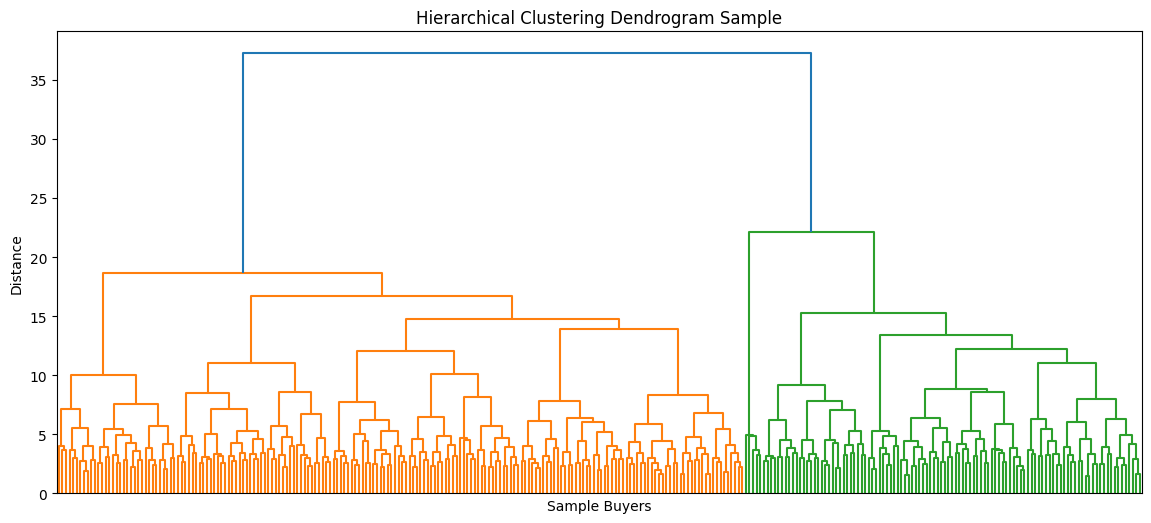


Saved file:
buyer_profile_with_kmeans_and_hierarchical.csv


In [9]:
# ==============================
# Step 5A: Hierarchical Clustering Validation
# ==============================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------
# 1. Train Hierarchical Clustering model
# ------------------------------

hierarchical_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

buyer_profile["hierarchical_cluster"] = hierarchical_model.fit_predict(X_cluster)

# ------------------------------
# 2. Evaluation
# ------------------------------

hierarchical_silhouette = silhouette_score(
    X_cluster,
    buyer_profile["hierarchical_cluster"]
)

kmeans_hierarchical_similarity = adjusted_rand_score(
    buyer_profile["cluster"],
    buyer_profile["hierarchical_cluster"]
)

print("Hierarchical Clustering completed successfully!")
print("Number of hierarchical clusters:", 4)
print("Hierarchical Silhouette Score:", hierarchical_silhouette)
print("K-Means Silhouette Score:", final_silhouette)
print("Adjusted Rand Score between K-Means and Hierarchical:", kmeans_hierarchical_similarity)

print("\nHierarchical Cluster Counts:")
print(buyer_profile["hierarchical_cluster"].value_counts().sort_index())

print("\nHierarchical Cluster Percentage Distribution:")
print((buyer_profile["hierarchical_cluster"].value_counts(normalize=True).sort_index() * 100).round(2))

# ------------------------------
# 3. Compare K-Means clusters with Hierarchical clusters
# ------------------------------

comparison_table = pd.crosstab(
    buyer_profile["cluster"],
    buyer_profile["hierarchical_cluster"],
    rownames=["KMeans Cluster"],
    colnames=["Hierarchical Cluster"]
)

print("\nK-Means vs Hierarchical Cluster Comparison:")
display(comparison_table)

# ------------------------------
# 4. Dendrogram on a sample
# Full 2000 rows can make the dendrogram too messy
# ------------------------------

sample_size = 300
sample_data = X_cluster.sample(n=sample_size, random_state=42)

plt.figure(figsize=(14, 6))
dendrogram = sch.dendrogram(
    sch.linkage(sample_data, method="ward"),
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram Sample")
plt.xlabel("Sample Buyers")
plt.ylabel("Distance")
plt.show()

# Save updated buyer profile
buyer_profile.to_csv("buyer_profile_with_kmeans_and_hierarchical.csv", index=False)

print("\nSaved file:")
print("buyer_profile_with_kmeans_and_hierarchical.csv")

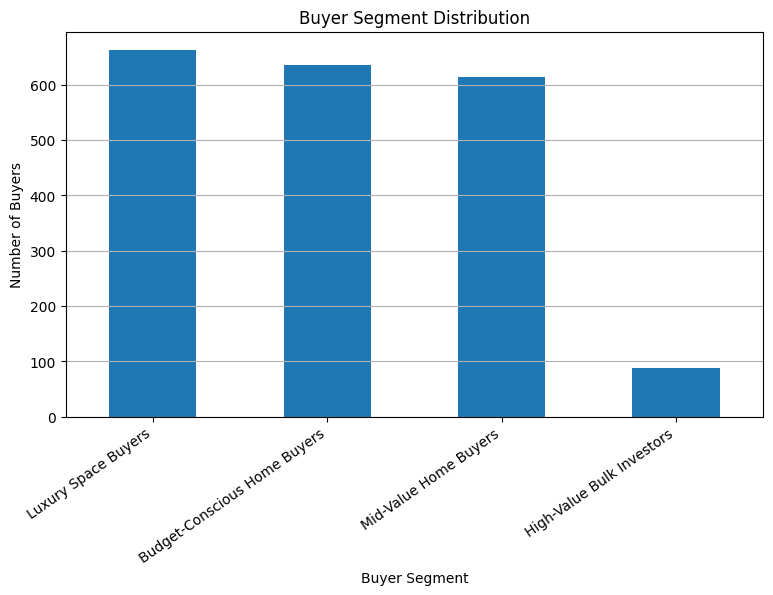

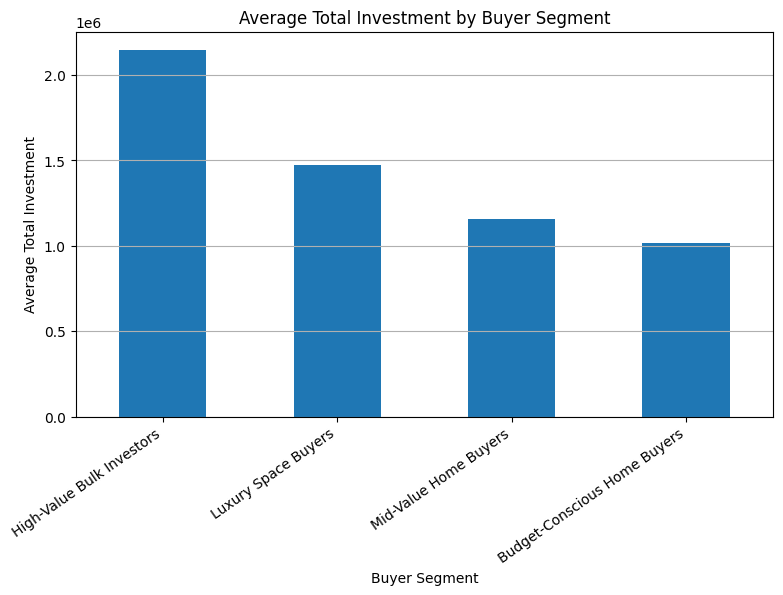

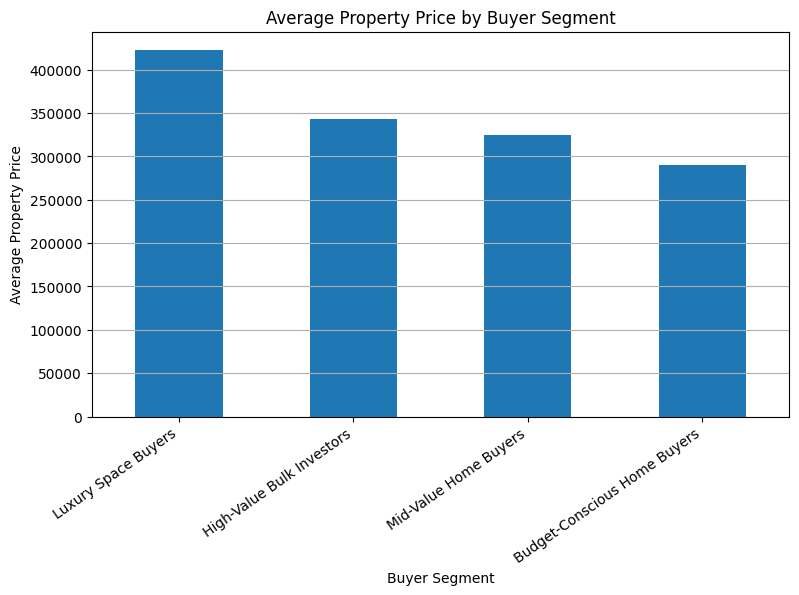

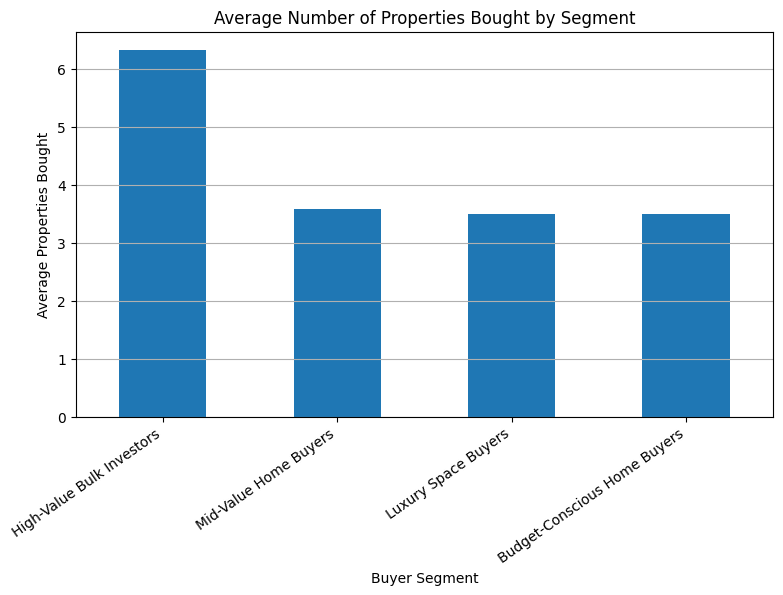

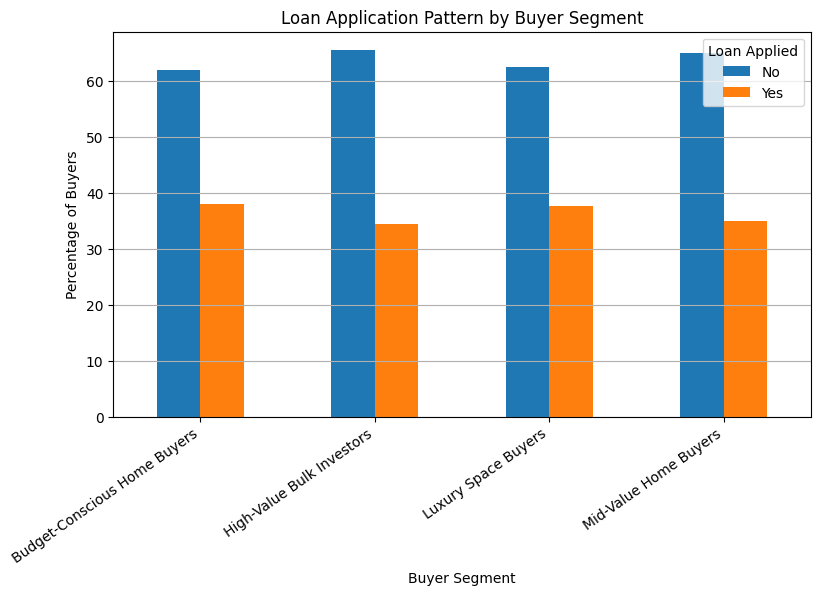

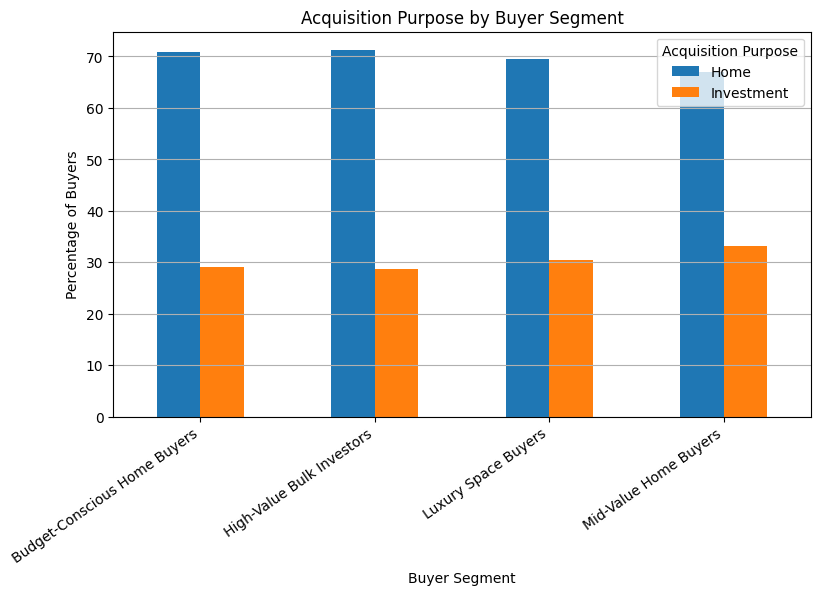

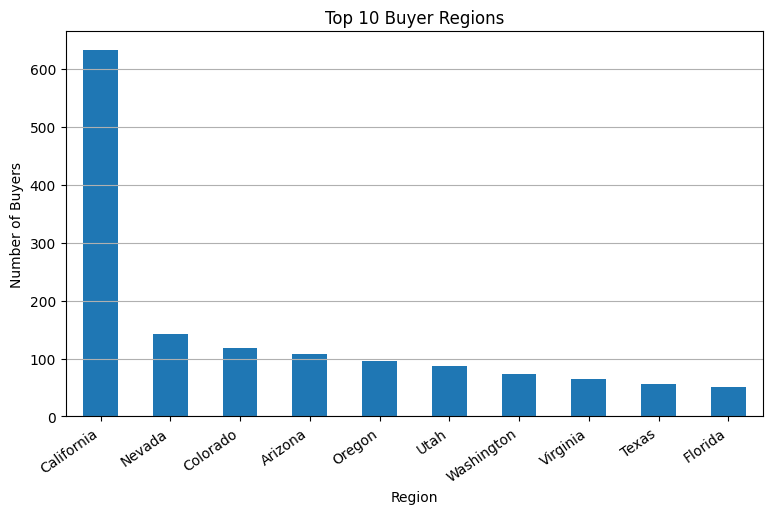

Final Visual Summary Table:


,buyer_segment,buyer_count,avg_age,avg_satisfaction,avg_properties_bought,avg_total_investment,avg_property_price,avg_floor_area_sqft,avg_investment_per_sqft
0,Budget-Conscious Home Buyers,636,56.08,3.10,3.50,1014331.96,290608.10,1011.85,287.82
1,High-Value Bulk Investors,87,63.68,3.53,6.33,2147601.19,342983.85,1138.88,301.26
2,Luxury Space Buyers,663,54.45,3.06,3.51,1474309.47,422852.25,1387.30,304.86
3,Mid-Value Home Buyers,614,54.91,2.85,3.59,1158513.61,324368.94,1030.22,315.16



Saved file:
visual_summary.csv


In [10]:
# ==============================
# Step 6A: Visualizations for Final Report
# ==============================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make sure buyer_segment exists
buyer_profile["buyer_segment"] = buyer_profile["cluster"].map(cluster_name_map)

# ------------------------------
# 1. Buyer Segment Distribution
# ------------------------------

plt.figure(figsize=(9, 5))
buyer_profile["buyer_segment"].value_counts().plot(kind="bar")
plt.title("Buyer Segment Distribution")
plt.xlabel("Buyer Segment")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

# ------------------------------
# 2. Average Total Investment by Segment
# ------------------------------

avg_investment_segment = buyer_profile.groupby("buyer_segment")["total_investment"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_investment_segment.plot(kind="bar")
plt.title("Average Total Investment by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Total Investment")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

# ------------------------------
# 3. Average Property Price by Segment
# ------------------------------

avg_price_segment = buyer_profile.groupby("buyer_segment")["avg_property_price"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_price_segment.plot(kind="bar")
plt.title("Average Property Price by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Property Price")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

# ------------------------------
# 4. Average Properties Bought by Segment
# ------------------------------

avg_properties_segment = buyer_profile.groupby("buyer_segment")["total_properties_bought"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_properties_segment.plot(kind="bar")
plt.title("Average Number of Properties Bought by Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Properties Bought")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

# ------------------------------
# 5. Loan Status by Segment
# ------------------------------

loan_segment = pd.crosstab(
    buyer_profile["buyer_segment"],
    buyer_profile["loan_applied"],
    normalize="index"
) * 100

loan_segment.plot(kind="bar", figsize=(9, 5))
plt.title("Loan Application Pattern by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Percentage of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.legend(title="Loan Applied")
plt.show()

# ------------------------------
# 6. Acquisition Purpose by Segment
# ------------------------------

purpose_segment = pd.crosstab(
    buyer_profile["buyer_segment"],
    buyer_profile["acquisition_purpose"],
    normalize="index"
) * 100

purpose_segment.plot(kind="bar", figsize=(9, 5))
plt.title("Acquisition Purpose by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Percentage of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.legend(title="Acquisition Purpose")
plt.show()

# ------------------------------
# 7. Top Regions by Buyer Count
# ------------------------------

top_regions = buyer_profile["region"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_regions.plot(kind="bar")
plt.title("Top 10 Buyer Regions")
plt.xlabel("Region")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()

# ------------------------------
# 8. Segment-wise Summary Table for Report
# ------------------------------

visual_summary = buyer_profile.groupby("buyer_segment").agg(
    buyer_count=("client_id", "count"),
    avg_age=("age", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_properties_bought=("total_properties_bought", "mean"),
    avg_total_investment=("total_investment", "mean"),
    avg_property_price=("avg_property_price", "mean"),
    avg_floor_area_sqft=("avg_floor_area_sqft", "mean"),
    avg_investment_per_sqft=("investment_per_sqft", "mean")
).round(2).reset_index()

print("Final Visual Summary Table:")
display(visual_summary)

visual_summary.to_csv("visual_summary.csv", index=False)

print("\nSaved file:")
print("visual_summary.csv")

In [11]:
# ==============================
# Step 6B: Segment Insights and Recommendations
# ==============================

import pandas as pd

segment_insights = pd.DataFrame({
    "buyer_segment": [
        "Budget-Conscious Home Buyers",
        "High-Value Bulk Investors",
        "Luxury Space Buyers",
        "Mid-Value Home Buyers"
    ],

    "segment_profile": [
        "Buyers with the lowest average total investment and lowest average property price. They mainly prefer affordable residential properties.",
        "Small but highly valuable buyer group with the highest number of properties purchased and the highest total investment.",
        "Buyers who prefer large and premium properties, with the highest average property price and highest average floor area.",
        "Middle-tier buyers with moderate investment levels and relatively high investment per square foot."
    ],

    "business_opportunity": [
        "Large buyer base suitable for affordable housing campaigns and entry-level property recommendations.",
        "High revenue potential due to repeated purchases and larger total investment volume.",
        "Strong opportunity for premium property marketing, luxury units, and spacious apartments.",
        "Good target for upgrade-based campaigns and personalized mid-range property recommendations."
    ],

    "recommended_strategy": [
        "Promote budget-friendly properties, flexible payment options, and loan-support messaging.",
        "Offer exclusive investor packages, early access to new listings, portfolio deals, and premium relationship management.",
        "Recommend luxury apartments, larger floor-area units, premium locations, and lifestyle-based property campaigns.",
        "Use personalized recommendations based on price-per-square-foot value, location preference, and moderate investment capacity."
    ],

    "marketing_channel_focus": [
        "Website campaigns, affordable property newsletters, and loan-assistance promotions.",
        "Direct client relationship, agency network, private investor outreach, and high-value deal alerts.",
        "Premium digital ads, curated luxury listings, website personalization, and lifestyle campaigns.",
        "Website recommendations, retargeting ads, and personalized email campaigns."
    ]
})

# Merge with visual summary to create one final interpretation table
final_segment_insights = visual_summary.merge(
    segment_insights,
    on="buyer_segment",
    how="left"
)

print("Final Segment Insights and Recommendations:")
display(final_segment_insights)

# Save for report/dashboard
final_segment_insights.to_csv("final_segment_insights.csv", index=False)

print("\nSaved file:")
print("final_segment_insights.csv")

Final Segment Insights and Recommendations:


,buyer_segment,buyer_count,avg_age,avg_satisfaction,avg_properties_bought,avg_total_investment,avg_property_price,avg_floor_area_sqft,avg_investment_per_sqft,segment_profile,business_opportunity,recommended_strategy,marketing_channel_focus
0,Budget-Conscious Home Buyers,636,56.08,3.10,3.50,1014331.96,290608.10,1011.85,287.82,Buyers with the lowest average total investmen...,Large buyer base suitable for affordable housi...,"Promote budget-friendly properties, flexible p...","Website campaigns, affordable property newslet..."
1,High-Value Bulk Investors,87,63.68,3.53,6.33,2147601.19,342983.85,1138.88,301.26,Small but highly valuable buyer group with the...,High revenue potential due to repeated purchas...,"Offer exclusive investor packages, early acces...","Direct client relationship, agency network, pr..."
2,Luxury Space Buyers,663,54.45,3.06,3.51,1474309.47,422852.25,1387.30,304.86,Buyers who prefer large and premium properties...,Strong opportunity for premium property market...,"Recommend luxury apartments, larger floor-area...","Premium digital ads, curated luxury listings, ..."
3,Mid-Value Home Buyers,614,54.91,2.85,3.59,1158513.61,324368.94,1030.22,315.16,Middle-tier buyers with moderate investment le...,Good target for upgrade-based campaigns and pe...,Use personalized recommendations based on pric...,"Website recommendations, retargeting ads, and ..."



Saved file:
final_segment_insights.csv


In [19]:
# ==========================================================
# PROJECT WORK - 01
# Save All CSV Files, Graphs, Model Files, and Final ZIP
# ==========================================================

import os
import json
import shutil
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

# ----------------------------------------------------------
# 1. Create output folders
# ----------------------------------------------------------

output_dir = "Project_Work_01_Final_Outputs"
csv_dir = os.path.join(output_dir, "csv_files")
image_dir = os.path.join(output_dir, "images")
model_dir = os.path.join(output_dir, "model_files")
dashboard_dir = os.path.join(output_dir, "dashboard_files")

for folder in [output_dir, csv_dir, image_dir, model_dir, dashboard_dir]:
    os.makedirs(folder, exist_ok=True)

print("Output folders created successfully.")

# ----------------------------------------------------------
# 2. Save all important CSV files
# ----------------------------------------------------------

csv_files = {
    "clients_clean.csv": clients_clean,
    "properties_clean.csv": properties_clean,
    "sold_properties.csv": sold_properties,
    "merged_data.csv": merged_data,
    "buyer_profile_with_segments.csv": buyer_profile,
    "segment_summary.csv": segment_summary,
    "cluster_profile_summary.csv": cluster_profile_summary,
    "visual_summary.csv": visual_summary,
    "final_segment_insights.csv": final_segment_insights,
    "kmeans_evaluation_results.csv": kmeans_eval,
    "kmeans_vs_hierarchical_comparison.csv": comparison_table,
    "encoded_scaled_clustering_data.csv": X_encoded
}

for filename, dataframe in csv_files.items():
    file_path = os.path.join(csv_dir, filename)
    dataframe.to_csv(file_path, index=True if filename == "kmeans_vs_hierarchical_comparison.csv" else False)
    print(f"Saved: {file_path}")

# ----------------------------------------------------------
# 3. Save model and preprocessing files
# ----------------------------------------------------------

with open(os.path.join(model_dir, "final_kmeans_model.pkl"), "wb") as f:
    pickle.dump(final_kmeans, f)

with open(os.path.join(model_dir, "standard_scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(model_dir, "cluster_name_map.json"), "w") as f:
    json.dump(cluster_name_map, f, indent=4)

feature_info = {
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "final_k": final_k,
    "final_kmeans_silhouette_score": float(final_silhouette),
    "hierarchical_silhouette_score": float(hierarchical_silhouette),
    "adjusted_rand_score_kmeans_vs_hierarchical": float(kmeans_hierarchical_similarity)
}

with open(os.path.join(model_dir, "model_metadata.json"), "w") as f:
    json.dump(feature_info, f, indent=4)

print("\nModel and metadata files saved successfully.")

# ----------------------------------------------------------
# 4. Save Streamlit dashboard file if app.py exists
# ----------------------------------------------------------

if os.path.exists("app.py"):
    shutil.copy("app.py", os.path.join(dashboard_dir, "app.py"))
    print("Saved dashboard app.py")
else:
    print("app.py not found. Skipping dashboard app file.")

# Create requirements.txt for Streamlit deployment
requirements_text = """streamlit
pandas
matplotlib
scikit-learn
scipy
"""

with open(os.path.join(dashboard_dir, "requirements.txt"), "w") as f:
    f.write(requirements_text)

print("Saved requirements.txt")

# ----------------------------------------------------------
# 5. Save all important graphs as PNG images
# ----------------------------------------------------------

# 5.1 Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "01_elbow_method.png"), dpi=300)
plt.close()

# 5.2 Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(kmeans_eval["k"], kmeans_eval["silhouette_score"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "02_silhouette_score.png"), dpi=300)
plt.close()

# 5.3 Buyer Segment Distribution
plt.figure(figsize=(9, 5))
buyer_profile["buyer_segment"].value_counts().plot(kind="bar")
plt.title("Buyer Segment Distribution")
plt.xlabel("Buyer Segment")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "03_buyer_segment_distribution.png"), dpi=300)
plt.close()

# 5.4 Average Total Investment by Segment
avg_investment_segment = buyer_profile.groupby("buyer_segment")["total_investment"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_investment_segment.plot(kind="bar")
plt.title("Average Total Investment by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Total Investment")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "04_avg_total_investment_by_segment.png"), dpi=300)
plt.close()

# 5.5 Average Property Price by Segment
avg_price_segment = buyer_profile.groupby("buyer_segment")["avg_property_price"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_price_segment.plot(kind="bar")
plt.title("Average Property Price by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Property Price")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "05_avg_property_price_by_segment.png"), dpi=300)
plt.close()

# 5.6 Average Properties Bought by Segment
avg_properties_segment = buyer_profile.groupby("buyer_segment")["total_properties_bought"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_properties_segment.plot(kind="bar")
plt.title("Average Number of Properties Bought by Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Average Properties Bought")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "06_avg_properties_bought_by_segment.png"), dpi=300)
plt.close()

# 5.7 Loan Status by Segment
loan_segment = pd.crosstab(
    buyer_profile["buyer_segment"],
    buyer_profile["loan_applied"],
    normalize="index"
) * 100

loan_segment.plot(kind="bar", figsize=(9, 5))
plt.title("Loan Application Pattern by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Percentage of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.legend(title="Loan Applied")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "07_loan_pattern_by_segment.png"), dpi=300)
plt.close()

# 5.8 Acquisition Purpose by Segment
purpose_segment = pd.crosstab(
    buyer_profile["buyer_segment"],
    buyer_profile["acquisition_purpose"],
    normalize="index"
) * 100

purpose_segment.plot(kind="bar", figsize=(9, 5))
plt.title("Acquisition Purpose by Buyer Segment")
plt.xlabel("Buyer Segment")
plt.ylabel("Percentage of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.legend(title="Acquisition Purpose")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "08_acquisition_purpose_by_segment.png"), dpi=300)
plt.close()

# 5.9 Top 10 Buyer Regions
top_regions = buyer_profile["region"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_regions.plot(kind="bar")
plt.title("Top 10 Buyer Regions")
plt.xlabel("Region")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "09_top_10_buyer_regions.png"), dpi=300)
plt.close()

# 5.10 Top 10 Buyer Countries
top_countries = buyer_profile["country"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Buyer Countries")
plt.xlabel("Country")
plt.ylabel("Number of Buyers")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "10_top_10_buyer_countries.png"), dpi=300)
plt.close()

# 5.11 Hierarchical Dendrogram Sample
sample_size = 300
sample_data = X_cluster.sample(n=sample_size, random_state=42)

plt.figure(figsize=(14, 6))
sch.dendrogram(
    sch.linkage(sample_data, method="ward"),
    no_labels=True
)
plt.title("Hierarchical Clustering Dendrogram Sample")
plt.xlabel("Sample Buyers")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(os.path.join(image_dir, "11_hierarchical_dendrogram_sample.png"), dpi=300)
plt.close()

print("\nAll graph images saved successfully.")

# ----------------------------------------------------------
# 6. Save a simple project README file
# ----------------------------------------------------------

readme_text = """
PROJECT WORK - 01
Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

Main Outputs:
1. Cleaned client and property datasets
2. Buyer-level profile dataset
3. Encoded and scaled clustering dataset
4. K-Means clustering results
5. Hierarchical clustering validation
6. Final buyer segments
7. Segment insights and recommendations
8. Report-ready visualizations
9. Streamlit dashboard files

Final Buyer Segments:
- Budget-Conscious Home Buyers
- Mid-Value Home Buyers
- Luxury Space Buyers
- High-Value Bulk Investors

Model Used:
- K-Means Clustering as the final segmentation model
- Hierarchical Clustering as validation method

Important Files:
- csv_files/buyer_profile_with_segments.csv
- csv_files/final_segment_insights.csv
- csv_files/segment_summary.csv
- images/
- model_files/final_kmeans_model.pkl
- dashboard_files/app.py
"""

with open(os.path.join(output_dir, "README.txt"), "w") as f:
    f.write(readme_text)

print("README.txt saved successfully.")

# ----------------------------------------------------------
# 7. Create final ZIP file
# ----------------------------------------------------------

zip_filename = "Project_Work_01_Final_Outputs"

# Remove old zip if exists
if os.path.exists(zip_filename + ".zip"):
    os.remove(zip_filename + ".zip")

shutil.make_archive(zip_filename, "zip", output_dir)

print("\n====================================================")
print("ALL FILES SAVED SUCCESSFULLY!")
print("Final ZIP created:")
print(zip_filename + ".zip")
print("====================================================")

Output folders created successfully.
Saved: Project_Work_01_Final_Outputs/csv_files/clients_clean.csv
Saved: Project_Work_01_Final_Outputs/csv_files/properties_clean.csv
Saved: Project_Work_01_Final_Outputs/csv_files/sold_properties.csv
Saved: Project_Work_01_Final_Outputs/csv_files/merged_data.csv
Saved: Project_Work_01_Final_Outputs/csv_files/buyer_profile_with_segments.csv
Saved: Project_Work_01_Final_Outputs/csv_files/segment_summary.csv
Saved: Project_Work_01_Final_Outputs/csv_files/cluster_profile_summary.csv
Saved: Project_Work_01_Final_Outputs/csv_files/visual_summary.csv
Saved: Project_Work_01_Final_Outputs/csv_files/final_segment_insights.csv
Saved: Project_Work_01_Final_Outputs/csv_files/kmeans_evaluation_results.csv
Saved: Project_Work_01_Final_Outputs/csv_files/kmeans_vs_hierarchical_comparison.csv
Saved: Project_Work_01_Final_Outputs/csv_files/encoded_scaled_clustering_data.csv

Model and metadata files saved successfully.
Saved dashboard app.py
Saved requirements.txt

Al

In [20]:
from google.colab import files

files.download("Project_Work_01_Final_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>